In [3]:
%matplotlib inline
import torch
from d2l import torch as d2l

img = d2l.plt.imread('./catdog.jpg')
# . 表示：当前目录
# .. 表示：上一级目
# img 形状一般是：
# 彩色图：(H, W, 3) 或 (H, W, 4)（RGBA）
# 灰度图：(H, W)
h, w = img.shape[:2]
h, w

(551, 700)

In [4]:
def display_anchors(fmap_w, fmap_h, s):
    d2l.set_figsize()
    # 前两个维度上的值不影响输出
    fmap = torch.zeros((1, 10, fmap_h, fmap_w))
    anchors = d2l.multibox_prior(fmap, sizes=s, ratios=[1, 2, 0.5])
    bbox_scale = torch.tensor((w, h, w, h))
    d2l.show_bboxes(d2l.plt.imshow(img).axes,
                    anchors[0] * bbox_scale)
    d2l.plt.imshow(img).axes

# imshow(img)：把图片显示出来
# .axes：拿到这张图所在的坐标轴对象（Axes），用于后续在同一张图上叠加画框
# (2) anchors[0] * bbox_scale
# anchors 形状 (1, N, 4)，anchors[0] 取出第 0 个 batch，变成 (N, 4)
# 乘 bbox_scale：
# 利用广播机制把每个框的四个坐标都转换到像素尺度
# 得到 (N, 4) 的像素坐标框
# (3) d2l.show_bboxes(axes, boxes)
# 在 axes 上绘制这些框（通常画矩形边框）

C:\Users\32536\anaconda3\envs\d2l-env\lib\site-packages\torch\functional.py:478: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:2895.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


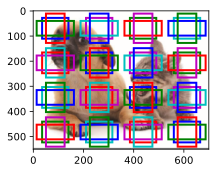

In [5]:
display_anchors(fmap_w=4, fmap_h=4, s=[0.15])

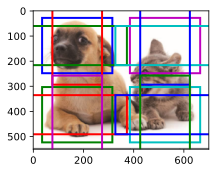

In [6]:
display_anchors(fmap_w=2, fmap_h=2, s=[0.4])

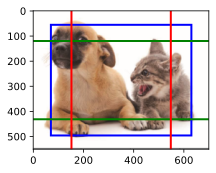

In [7]:
display_anchors(fmap_w=1, fmap_h=1, s=[0.8])